# Лабораторная работа №3: Аппроксимация функции с помощью двухслойной нейронной сети

**Дисциплина:** Генетические и эволюционные вычисления

**Цель работы:** реализовать двухслойную нейронную сеть для аппроксимации заданной функции и исследовать влияние количества нейронов в скрытом слое на качество аппроксимации.

### Описание подхода

Аппроксимируемая функция: $y(x) = \sin(x) \cdot \cos(2x) + 0{,}5$, $x \in [-2\pi,\; 2\pi]$.

Архитектура нейронной сети:
- **Входной слой:** 1 нейрон (значение $x$)
- **Скрытый слой:** $n$ нейронов с функцией активации $\tanh$
- **Выходной слой:** 1 нейрон с линейной функцией активации

Обучение выполняется методом градиентного спуска (обратное распространение ошибки) с функцией потерь MSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

os.makedirs('outputs', exist_ok=True)
np.random.seed(42)

## Целевая функция

Определим целевую функцию $y(x) = \sin(x) \cdot \cos(2x) + 0{,}5$ и визуализируем её на отрезке $[-2\pi,\; 2\pi]$.

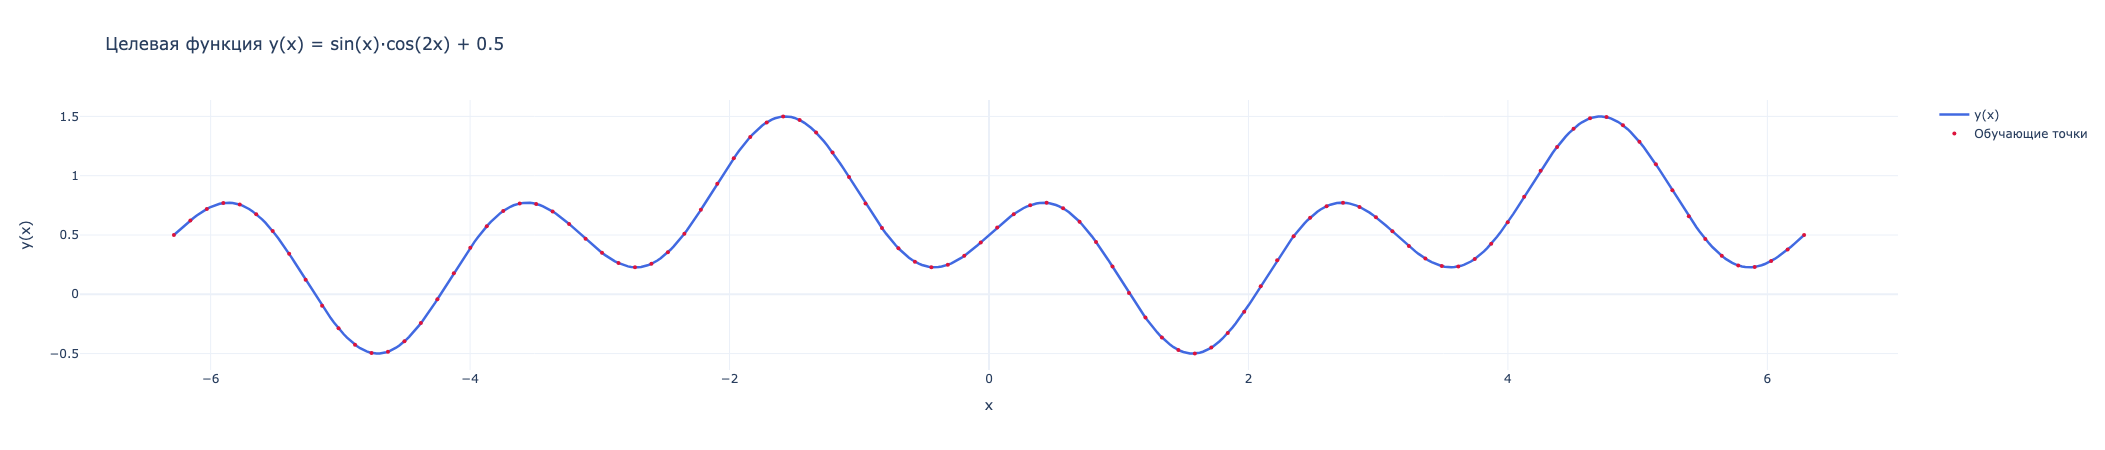

In [2]:
def target_function(x):
    return np.sin(x) * np.cos(2 * x) + 0.5


x_train = np.linspace(-2 * np.pi, 2 * np.pi, 100).reshape(-1, 1)
y_train = target_function(x_train)

x_plot = np.linspace(-2 * np.pi, 2 * np.pi, 500).reshape(-1, 1)
y_plot = target_function(x_plot)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_plot.flatten(), y=y_plot.flatten(),
    mode='lines', name='y(x)',
    line=dict(color='royalblue', width=2.5)
))
fig.add_trace(go.Scatter(
    x=x_train.flatten(), y=y_train.flatten(),
    mode='markers', name='Обучающие точки',
    marker=dict(color='crimson', size=4)
))
fig.update_layout(
    title='Целевая функция y(x) = sin(x)·cos(2x) + 0.5',
    xaxis_title='x', yaxis_title='y(x)',
    template='plotly_white', width=850, height=450
)
fig.write_html('outputs/target_function.html')
fig.show()

## Реализация двухслойной нейронной сети

Реализуем нейронную сеть с нуля, используя только NumPy.

**Прямое распространение (forward pass):**
$$h = \tanh(W_1 x + b_1)$$
$$\hat{y} = W_2 h + b_2$$

**Функция потерь (MSE):**
$$L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

**Обратное распространение (backward pass):**

Градиенты вычисляются по цепному правилу для обновления весов $W_1, b_1, W_2, b_2$ методом градиентного спуска.

In [3]:
class NeuralNetwork:
    """Двухслойная нейронная сеть для аппроксимации функций."""

    def __init__(self, hidden_size, learning_rate=0.05):
        self.hidden_size = hidden_size
        self.lr = learning_rate

        # Xavier-подобная инициализация весов
        self.W1 = np.random.randn(1, hidden_size) * np.sqrt(2.0 / (1 + hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, 1) * np.sqrt(2.0 / (hidden_size + 1))
        self.b2 = np.zeros((1, 1))

        self.loss_history = []

    def forward(self, x):
        self.x = x
        self.z1 = x @ self.W1 + self.b1          # (N, hidden)
        self.h = np.tanh(self.z1)                  # (N, hidden)
        self.z2 = self.h @ self.W2 + self.b2      # (N, 1)
        return self.z2

    def backward(self, y_true):
        N = y_true.shape[0]
        # dL/dz2 = 2/N * (y_pred - y_true)
        dz2 = (2.0 / N) * (self.z2 - y_true)     # (N, 1)

        dW2 = self.h.T @ dz2                       # (hidden, 1)
        db2 = np.sum(dz2, axis=0, keepdims=True)   # (1, 1)

        dh = dz2 @ self.W2.T                       # (N, hidden)
        dz1 = dh * (1.0 - self.h ** 2)            # tanh': 1 - tanh^2

        dW1 = self.x.T @ dz1                       # (1, hidden)
        db1 = np.sum(dz1, axis=0, keepdims=True)   # (1, hidden)

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def train(self, x, y, epochs=600, target_error=1e-2, show_every=50, verbose=True):
        self.loss_history = []
        for epoch in range(1, epochs + 1):
            y_pred = self.forward(x)
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            self.backward(y)

            if verbose and epoch % show_every == 0:
                print(f'  Эпоха {epoch:>4d}/{epochs} | MSE = {loss:.6f}')

            if loss <= target_error:
                if verbose:
                    print(f'  ✓ Целевая ошибка {target_error} достигнута на эпохе {epoch} (MSE = {loss:.6f})')
                break

        if verbose and loss > target_error:
            print(f'  Обучение завершено. Финальная MSE = {loss:.6f}')

        return self.loss_history

    def predict(self, x):
        z1 = x @ self.W1 + self.b1
        h = np.tanh(z1)
        return h @ self.W2 + self.b2

## Обучение и результаты

Обучим нейронную сеть с 20 нейронами в скрытом слое и визуализируем процесс обучения и качество аппроксимации.

In [4]:
# Нормализация входных данных для ускорения сходимости
x_mean, x_std = x_train.mean(), x_train.std()
x_norm = (x_train - x_mean) / x_std

nn = NeuralNetwork(hidden_size=20, learning_rate=0.05)
print('Обучение сети (20 нейронов в скрытом слое):')
loss_history = nn.train(x_norm, y_train, epochs=600, target_error=1e-2, show_every=50)

Обучение сети (20 нейронов в скрытом слое):
  Эпоха   50/600 | MSE = 0.239083
  Эпоха  100/600 | MSE = 0.238554
  Эпоха  150/600 | MSE = 0.238059
  Эпоха  200/600 | MSE = 0.237582
  Эпоха  250/600 | MSE = 0.237109
  Эпоха  300/600 | MSE = 0.236632
  Эпоха  350/600 | MSE = 0.236142
  Эпоха  400/600 | MSE = 0.235633
  Эпоха  450/600 | MSE = 0.235099
  Эпоха  500/600 | MSE = 0.234537
  Эпоха  550/600 | MSE = 0.233942
  Эпоха  600/600 | MSE = 0.233314
  Обучение завершено. Финальная MSE = 0.233314


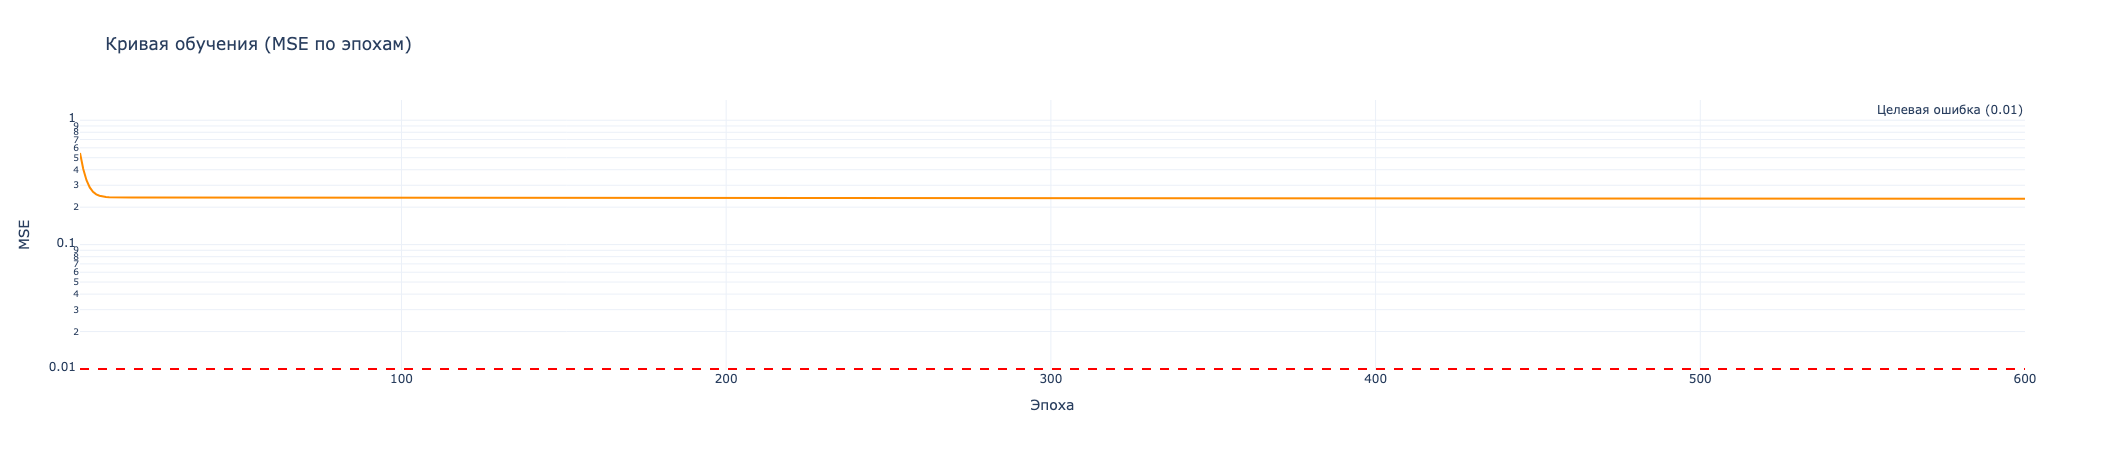

In [5]:
# Кривая обучения
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(
    x=list(range(1, len(loss_history) + 1)),
    y=loss_history,
    mode='lines', name='MSE',
    line=dict(color='darkorange', width=2)
))
fig_loss.add_hline(
    y=1e-2, line_dash='dash', line_color='red',
    annotation_text='Целевая ошибка (0.01)'
)
fig_loss.update_layout(
    title='Кривая обучения (MSE по эпохам)',
    xaxis_title='Эпоха', yaxis_title='MSE',
    yaxis_type='log',
    template='plotly_white', width=850, height=450
)
fig_loss.write_html('outputs/training_loss.html')
fig_loss.show()

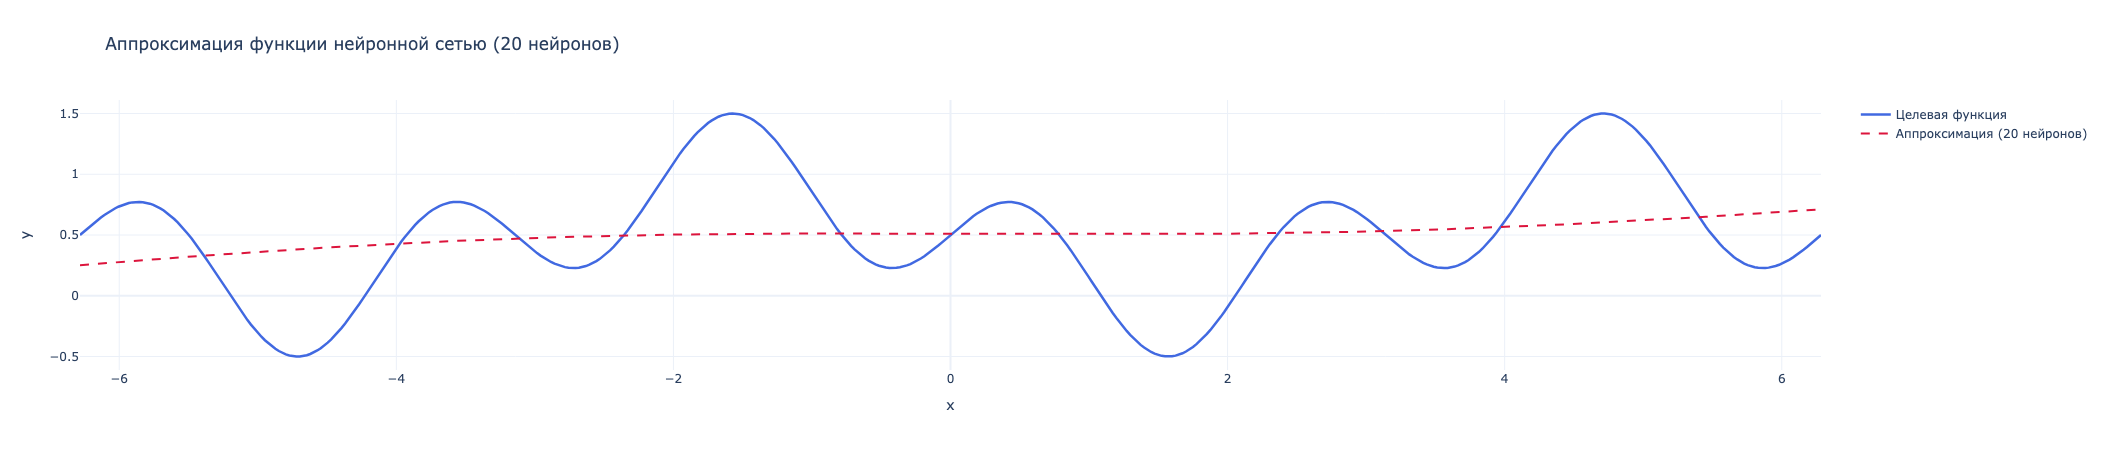

In [6]:
# Сравнение оригинальной функции и аппроксимации
x_plot_norm = (x_plot - x_mean) / x_std
y_pred_plot = nn.predict(x_plot_norm)

fig_approx = go.Figure()
fig_approx.add_trace(go.Scatter(
    x=x_plot.flatten(), y=y_plot.flatten(),
    mode='lines', name='Целевая функция',
    line=dict(color='royalblue', width=2.5)
))
fig_approx.add_trace(go.Scatter(
    x=x_plot.flatten(), y=y_pred_plot.flatten(),
    mode='lines', name='Аппроксимация (20 нейронов)',
    line=dict(color='crimson', width=2, dash='dash')
))
fig_approx.update_layout(
    title='Аппроксимация функции нейронной сетью (20 нейронов)',
    xaxis_title='x', yaxis_title='y',
    template='plotly_white', width=850, height=450
)
fig_approx.write_html('outputs/approximation_20neurons.html')
fig_approx.show()

## Анализ влияния количества нейронов

Исследуем, как количество нейронов в скрытом слое влияет на качество аппроксимации. Обучим сети с 5, 10, 20 и 50 нейронами.

In [7]:
hidden_sizes = [5, 10, 20, 50]
results = {}
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

for hs in hidden_sizes:
    print(f'\n--- Скрытый слой: {hs} нейронов ---')
    np.random.seed(42)
    net = NeuralNetwork(hidden_size=hs, learning_rate=0.05)
    losses = net.train(x_norm, y_train, epochs=600, target_error=1e-2, show_every=50)
    y_pred = net.predict(x_plot_norm)
    final_mse = losses[-1]
    results[hs] = {'losses': losses, 'y_pred': y_pred, 'mse': final_mse}
    print(f'  Итоговая MSE: {final_mse:.6f}')


--- Скрытый слой: 5 нейронов ---
  Эпоха   50/600 | MSE = 0.236689
  Эпоха  100/600 | MSE = 0.235864
  Эпоха  150/600 | MSE = 0.234933
  Эпоха  200/600 | MSE = 0.233875
  Эпоха  250/600 | MSE = 0.232665
  Эпоха  300/600 | MSE = 0.231283
  Эпоха  350/600 | MSE = 0.229713
  Эпоха  400/600 | MSE = 0.227946
  Эпоха  450/600 | MSE = 0.225984
  Эпоха  500/600 | MSE = 0.223839
  Эпоха  550/600 | MSE = 0.221536
  Эпоха  600/600 | MSE = 0.219110
  Обучение завершено. Финальная MSE = 0.219110
  Итоговая MSE: 0.219110

--- Скрытый слой: 10 нейронов ---
  Эпоха   50/600 | MSE = 0.236931
  Эпоха  100/600 | MSE = 0.236349
  Эпоха  150/600 | MSE = 0.235705
  Эпоха  200/600 | MSE = 0.234987
  Эпоха  250/600 | MSE = 0.234185
  Эпоха  300/600 | MSE = 0.233293
  Эпоха  350/600 | MSE = 0.232305
  Эпоха  400/600 | MSE = 0.231218
  Эпоха  450/600 | MSE = 0.230031
  Эпоха  500/600 | MSE = 0.228747
  Эпоха  550/600 | MSE = 0.227372
  Эпоха  600/600 | MSE = 0.225914
  Обучение завершено. Финальная MSE = 0.225

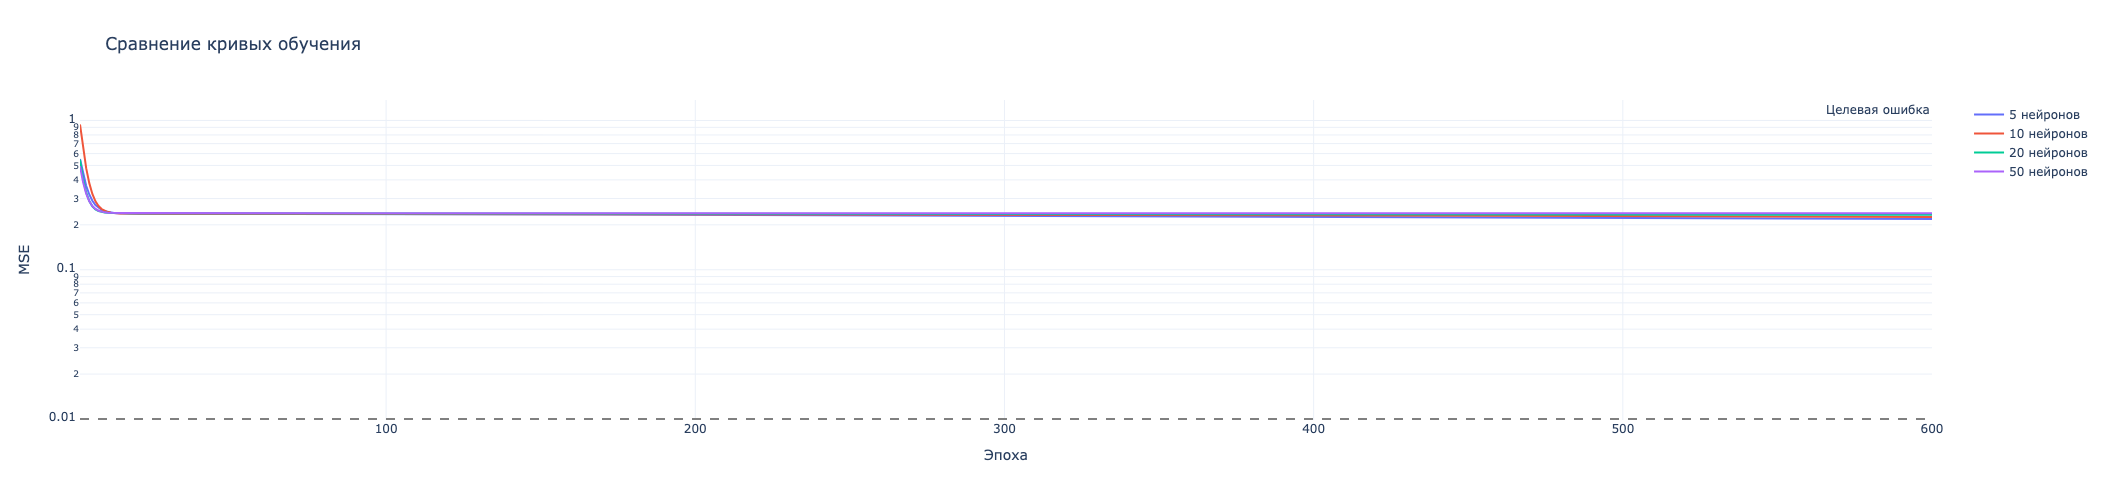

In [8]:
# Кривые обучения для всех конфигураций
fig_losses = go.Figure()
for hs, color in zip(hidden_sizes, colors):
    fig_losses.add_trace(go.Scatter(
        x=list(range(1, len(results[hs]['losses']) + 1)),
        y=results[hs]['losses'],
        mode='lines', name=f'{hs} нейронов',
        line=dict(color=color, width=2)
    ))
fig_losses.add_hline(
    y=1e-2, line_dash='dash', line_color='gray',
    annotation_text='Целевая ошибка'
)
fig_losses.update_layout(
    title='Сравнение кривых обучения',
    xaxis_title='Эпоха', yaxis_title='MSE',
    yaxis_type='log',
    template='plotly_white', width=850, height=500
)
fig_losses.write_html('outputs/loss_comparison.html')
fig_losses.show()

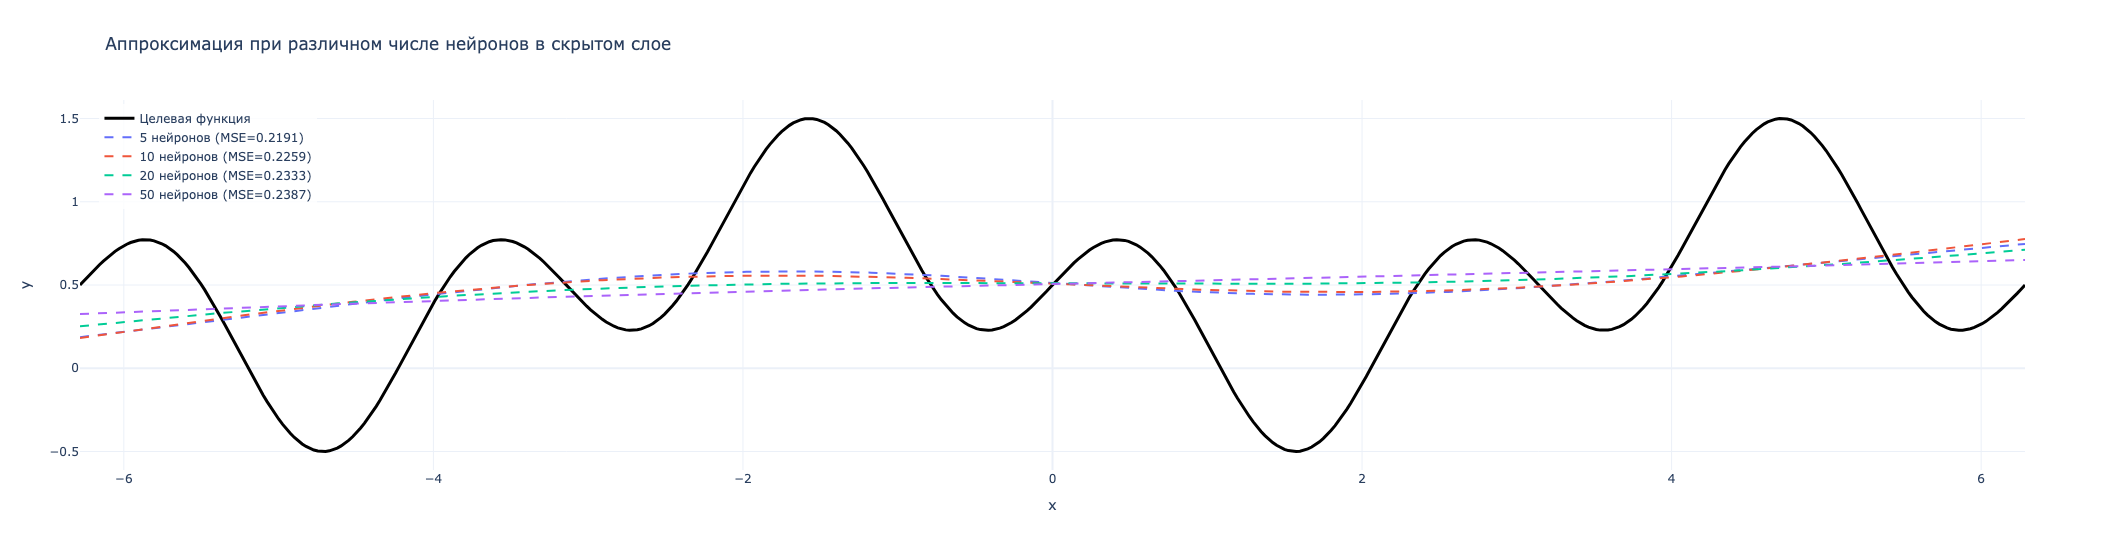

In [9]:
# Сравнение аппроксимаций
fig_cmp = go.Figure()
fig_cmp.add_trace(go.Scatter(
    x=x_plot.flatten(), y=y_plot.flatten(),
    mode='lines', name='Целевая функция',
    line=dict(color='black', width=3)
))
for hs, color in zip(hidden_sizes, colors):
    fig_cmp.add_trace(go.Scatter(
        x=x_plot.flatten(), y=results[hs]['y_pred'].flatten(),
        mode='lines', name=f'{hs} нейронов (MSE={results[hs]["mse"]:.4f})',
        line=dict(color=color, width=2, dash='dash')
    ))
fig_cmp.update_layout(
    title='Аппроксимация при различном числе нейронов в скрытом слое',
    xaxis_title='x', yaxis_title='y',
    template='plotly_white', width=900, height=550,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)')
)
fig_cmp.write_html('outputs/approximation_comparison.html')
fig_cmp.show()

In [10]:
# Таблица результатов
print('Сводная таблица результатов:')
print(f'{"Нейронов":>10} | {"Финальная MSE":>15} | {"Эпох обучения":>15}')
print('-' * 48)
for hs in hidden_sizes:
    n_epochs = len(results[hs]['losses'])
    mse = results[hs]['mse']
    print(f'{hs:>10} | {mse:>15.6f} | {n_epochs:>15}')

Сводная таблица результатов:
  Нейронов |   Финальная MSE |   Эпох обучения
------------------------------------------------
         5 |        0.219110 |             600
        10 |        0.225914 |             600
        20 |        0.233314 |             600
        50 |        0.238719 |             600


## Выводы

1. **Двухслойная нейронная сеть** с функцией активации $\tanh$ в скрытом слое и линейным выходом способна аппроксимировать сложную нелинейную функцию $y(x) = \sin(x) \cdot \cos(2x) + 0{,}5$.

2. **Влияние числа нейронов в скрытом слое:**
   - При малом количестве нейронов (5) сеть имеет недостаточную ёмкость для точного приближения — наблюдается **недообучение**.
   - С увеличением числа нейронов (10, 20) качество аппроксимации значительно возрастает.
   - При большом количестве нейронов (50) сеть имеет достаточную ёмкость, однако обучение может быть менее стабильным.

3. **Нормализация входных данных** существенно ускоряет сходимость градиентного спуска.

4. **Скорость обучения** (learning rate = 0.05) — важный гиперпараметр: слишком высокое значение приводит к расходимости, слишком низкое — к медленной сходимости.

5. Результаты подтверждают **теорему об универсальной аппроксимации**: нейронная сеть с одним скрытым слоем и достаточным числом нейронов может приблизить любую непрерывную функцию с произвольной точностью.